<a href="https://colab.research.google.com/github/shaha219/learning-ai-ml/blob/main/ETL_Project_Traffic_Collisions_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Traffic Collision Data Analysis

# Objective

In this case study, you will be working on California Traffic Collision Data Analysis using Apache Spark, a powerful distributed computing framework designed for big data processing. This assignment aims to provide hands-on experience in analyzing large-scale traffic collision datasets using PySpark and AWS services. You will apply data analytics techniques to clean, transform, and explore crash data, drawing meaningful insights to support traffic safety and urban planning. Beyond understanding how big data tools optimize performance on a single machine and across clusters, you will develop a structured approach to analyzing crash trends, identifying high-risk locations, and evaluating contributing factors to traffic incidents. Additionally, you will utilize AWS S3 to store the processed data efficiently after the ETL process, enabling scalable storage and easy retrieval for further analysis.


# Business Value:

Traffic collisions pose significant risks to public safety, requiring continuous monitoring and analysis to enhance road safety measures. Government agencies, city planners, and policymakers must leverage data-driven insights to improve infrastructure, optimize traffic management, and implement preventive measures.

In this assignment, you will analyze California traffic collision data to uncover patterns related to accident severity, location-based risks, and key contributing factors. With Apache Spark's ability to handle large datasets efficiently and AWS S3's scalable storage, transportation authorities can process vast amounts of crash data in real time, enabling faster and more informed decision-making.

As an analyst examining traffic safety trends, your task is to analyze historical crash data to derive actionable insights that can drive policy improvements and safety interventions. Your analysis will help identify high-risk areas, categorize accidents by severity and contributing factors, and store the processed data in an AWS S3 bucket for scalable and long-term storage.

By leveraging big data analytics and cloud-based storage, urban planners and traffic authorities can enhance road safety strategies, reduce accident rates, and improve public transportation planning.


# Dataset Overview

The dataset used in this analysis consists of California traffic collision data obtained from the Statewide Integrated Traffic Records System (SWITRS). It includes detailed records of traffic incidents across California, covering various attributes such as location, severity, involved parties, and contributing factors. The dataset has been preprocessed and transformed using PySpark to facilitate large-scale analysis. By leveraging Apache Spark, we ensure efficient data handling, enabling deeper insights into traffic patterns, accident trends, and potential safety improvements.

The dataset is a .sqlite file contains detailed information about traffic collisions across California and is structured into four primary tables:
- `collisions` table contains information about the collision, where it happened, what vehicles were involved.

- `parties` table contains information about the groups people involved in the collision including age, sex, and sobriety.

- `victims` table contains information about the injuries of specific people involved in the collision.

- `locations` table contains information about the geographical location and details of road intersections.

# Assignment Tasks

<ol>
    <li>
        <strong>Data Preparation</strong></br>
        The dataset consists of structured tables containing traffic collision data. Before conducting any analysis, it is essential to ensure that the data is properly formatted and structured for efficient processing.</br>
        Check for data consistency and ensure all columns are correctly formatted.</br>
        Apply sampling techniques if needed to extract a representative subset for analysis.</br>
        Structure and prepare the data for further processing and analysis.</br>
    </br>
    <li>
        <strong>Data Cleaning</strong></br>
            2.1 <strong>Fixing Columns:</strong> Ensure all columns are properly named and formatted.</br>
            2.2 <strong>Handling Missing Values:</strong> Decide on an approach to handle missing data (e.g., imputation or removal). Mention the approach in your report.</br>
            2.3 <strong>Handling Outliers:</strong> Identify outliers in the dataset and explain why they are considered outliers. It is not necessary to remove them for this task, but mention your approach for handling them.</br>
    </br>
    <li>
        <strong>Exploratory Data Analysis</strong></br>
        Finding Patterns and analyze the dataset and find patterns based on the following points:
                <ul>
                3.1 Classify variables into categorical and numerical types.</br>
                3.2 Analyze the distribution of collision severity.</br>
                3.3 Examine weather conditions during collisions.</br>
                3.4 Analyze the distribution of victim ages.</br>
                3.5 Study the relationship between collision severity and the number of victims.</br>
                3.6 Analyze the correlation between weather conditions and collision severity.</br>
                3.7 Visualize the impact of lighting conditions on collision severity.</br>
                3.8 Extract and analyze weekday-wise collision trends.</br>
                3.9 Assess the number of collisions occurring on different days of the week.</br>
                3.10 Study spatial distribution of collisions by county.</br>
                3.11 Generate a scatter plot to analyze collision locations geographically.</br>
                3.12 Extract and analyze collision trends over time, including yearly, monthly, and hourly trends.</br>
</ul>
</br>
<li>
<strong>ETL Querying</strong><br>
Write PySpark SQL queries for the following:</br>
<ol>
    4.1. Identify the top 5 counties with the highest number of collisions.</br>
    4.2. Identify the month with the highest number of collisions.</br>
    4.3. Determine the most common weather condition during collisions.</br>
    4.4. Calculate the percentage of collisions that resulted in fatalities.</br>
    4.5. Find the most dangerous time of day for collisions.</br>
    4.6. Identify the top 5 road surface conditions with the highest collision frequency.</br>
    4.7. Analyze lighting conditions that contribute to the highest number of collisions.</br>
</ol>
</br>
<li>
<strong>Conclusion</strong></br>
Provide final insights and recommendations based on the analysis:
    <ul>
        5.1 Recommendations to improve road safety by identifying high-risk locations and peak accident times for infrastructure improvements.</br>
        5.2 Suggestions to optimize traffic management by analyzing trends in collision severity, weather conditions, and lighting to improve road design and traffic signal timing.</br>
        5.3 Propose data-driven policy changes to enhance pedestrian and cyclist safety based on collision trends involving vulnerable road users.</br>
        5.4 Identify potential high-risk zones for proactive intervention by examining geographic collision density and historical accident data.</br>
        5.5 Assess the impact of environmental factors such as weather, road surface conditions, and lighting on accident frequency and severity.</br>
        5.6 Develop predictive models to anticipate collision hotspots and support proactive safety measures.</br>
        </ul>
        Conclude the analysis by summarizing key findings and business implications.</br>
        Explain the results of univariate, segmented univariate, and bivariate analyses in real-world traffic safety and policy terms.</br>
        Include visualizations and summarize the most important results in the report. Insights should explain why each variable is important and how they can influence traffic safety policies and urban planning.</br>
        </ul>
        </br>
    <li>
    <strong>Visualization Integration [Optional]</strong>
    <p>Enhance the project by incorporating a visualization component that connects the processed data stored in an S3 bucket to a business intelligence tool such as Tableau or Power BI. This involves setting up the connection between the S3 bucket and the chosen visualization tool, importing the processed dataset for analysis and visualization, creating interactive dashboards to explore key trends and insights and ensuring data updates are reflected dynamically in the visualization tool.<br>
</br>
</ol>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Install Required Libraries

In [ ]:
## Install the required libraries
# !pip install --quiet pyspark==3.5.4 pandas==2.2.2

In [ ]:
# Import the necessary libraries
import sqlite3
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum, date_format, to_date, count, isnan, when
from pyspark.sql.types import StringType, IntegerType

#**1. Data Preparation** <font color = red>[5 marks]</font> <br>

The dataset consists of structured tables containing traffic collision data.

Before conducting any analysis, it is essential to ensure that the data is properly formatted and structured for efficient processing.

Check for data consistency and ensure all columns are correctly formatted.

In [ ]:
# Write code to load the data and check the schema
# import zipfile
# import os

# # Initialize a basic local Spark session
# spark = SparkSession.builder \
#     .appName("TrafficCollisionAnalysis") \
#     .getOrCreate()

# # Verify your session is running
# print(f"Spark Version: {spark.version}")

# # 1. Define the paths (Update these with your actual file names!)
# zip_file_path = '/content/drive/MyDrive/Colab Notebooks/ETL-Project-Traffic-Collisions/Crash_Data_Analysis_Dataset/archive.zip'
# extracted_folder_path = '/content/drive/MyDrive/Colab Notebooks/ETL-Project-Traffic-Collisions/Crash_Data_Analysis_Dataset/extracted_data/'

# # 2. Extract the file
# with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
#     zip_ref.extractall(extracted_folder_path)
#     print("Files unzipped successfully to:", extracted_folder_path)

# # 3. List the files to confirm the exact name of your .sqlite file
# print(os.listdir(extracted_folder_path))

# # Connect to the unzipped SQLite database
# db_path = extracted_folder_path + 'switrs.sqlite'
# conn = sqlite3.connect(db_path)

# # Read the tables into Pandas, then convert to PySpark DataFrames
# df_collisions = spark.createDataFrame(pd.read_sql_query("SELECT * FROM collisions", conn))
# df_parties = spark.createDataFrame(pd.read_sql_query("SELECT * FROM parties", conn))
# df_victims = spark.createDataFrame(pd.read_sql_query("SELECT * FROM victims", conn))
# df_locations = spark.createDataFrame(pd.read_sql_query("SELECT * FROM locations", conn))

# # Verify the load by checking the schema
# print("Collisions Schema:")
# df_collisions.printSchema()

In [ ]:
# Write code to load the data and check the schema

# Initialize a basic local Spark session
spark = SparkSession.builder \
    .appName("TrafficCollisionAnalysis") \
    .getOrCreate()

# Verify your session is running
print(f"Spark Version: {spark.version}")

# Load the data
collisions_df = spark.read.csv('/content/drive/MyDrive/Colab Notebooks/ETL-Project-Traffic-Collisions/Crash_Data_Analysis_Dataset/sample_collisions.csv', header=True, inferSchema=True)
parties_df = spark.read.csv('/content/drive/MyDrive/Colab Notebooks/ETL-Project-Traffic-Collisions/Crash_Data_Analysis_Dataset/sample_parties.csv', header=True, inferSchema=True)
victims_df = spark.read.csv('/content/drive/MyDrive/Colab Notebooks/ETL-Project-Traffic-Collisions/Crash_Data_Analysis_Dataset/sample_victims.csv', header=True, inferSchema=True)

# Check the schema and display sample data
print("\nCollisions DataFrame Schema and Sample Data:")
collisions_df.printSchema()
collisions_df.show(5)

print("\nParties DataFrame Schema and Sample Data:")
parties_df.printSchema()
parties_df.show(5)

print("\nVictims DataFrame Schema and Sample Data:")
victims_df.printSchema()
victims_df.show(5)

Spark Version: 4.0.3

Collisions DataFrame Schema and Sample Data:
root
 |-- case_id: double (nullable = true)
 |-- jurisdiction: double (nullable = true)
 |-- officer_id: string (nullable = true)
 |-- reporting_district: string (nullable = true)
 |-- chp_shift: string (nullable = true)
 |-- population: string (nullable = true)
 |-- county_city_location: integer (nullable = true)
 |-- county_location: string (nullable = true)
 |-- special_condition: double (nullable = true)
 |-- beat_type: string (nullable = true)
 |-- chp_beat_type: string (nullable = true)
 |-- chp_beat_class: string (nullable = true)
 |-- beat_number: string (nullable = true)
 |-- primary_road: string (nullable = true)
 |-- secondary_road: string (nullable = true)
 |-- distance: double (nullable = true)
 |-- direction: string (nullable = true)
 |-- intersection: double (nullable = true)
 |-- weather_1: string (nullable = true)
 |-- state_highway_indicator: double (nullable = true)
 |-- caltrans_county: string (nulla

#**2. Data Cleaning** <font color = red>[20 marks]</font> <br>


In [ ]:
#Display Schema & Sample Data

print("\nCollisions DataFrame Schema and Sample Data:")
collisions_df.printSchema()
collisions_df.show(5)

print("\nParties DataFrame Schema and Sample Data:")
parties_df.printSchema()
parties_df.show(5)

print("\nVictims DataFrame Schema and Sample Data:")
victims_df.printSchema()
victims_df.show(5)


Collisions DataFrame Schema and Sample Data:
root
 |-- case_id: double (nullable = true)
 |-- jurisdiction: double (nullable = true)
 |-- officer_id: string (nullable = true)
 |-- reporting_district: string (nullable = true)
 |-- chp_shift: string (nullable = true)
 |-- population: string (nullable = true)
 |-- county_city_location: integer (nullable = true)
 |-- county_location: string (nullable = true)
 |-- special_condition: double (nullable = true)
 |-- beat_type: string (nullable = true)
 |-- chp_beat_type: string (nullable = true)
 |-- chp_beat_class: string (nullable = true)
 |-- beat_number: string (nullable = true)
 |-- primary_road: string (nullable = true)
 |-- secondary_road: string (nullable = true)
 |-- distance: double (nullable = true)
 |-- direction: string (nullable = true)
 |-- intersection: double (nullable = true)
 |-- weather_1: string (nullable = true)
 |-- state_highway_indicator: double (nullable = true)
 |-- caltrans_county: string (nullable = true)
 |-- calt

##**2.1 Missing Values** <font color = red>[10 marks]</font> <br>


In [ ]:
#Check for Missing Values


print("\nMissing values in collisions_df:")
# Create an empty list to hold our column checks
exprs_collisions = []
# Loop through columns and their data types
for c, t in collisions_df.dtypes:
    # If the column is a float or double, check for NaN AND Null
    if t in ('double', 'float'):
        exprs_collisions.append(count(when(isnan(c) | col(c).isNull(), c)).alias(c))
    # Otherwise, just check for Null
    else:
        exprs_collisions.append(count(when(col(c).isNull(), c)).alias(c))

collisions_df.select(exprs_collisions).show(vertical=True)

print("\nMissing values in parties_df:")
exprs_parties = []
for c, t in parties_df.dtypes:
    if t in ('double', 'float'):
        exprs_parties.append(count(when(isnan(c) | col(c).isNull(), c)).alias(c))
    else:
        exprs_parties.append(count(when(col(c).isNull(), c)).alias(c))

parties_df.select(exprs_parties).show(vertical=True)

print("\nMissing values in victims_df:")
exprs_victims = []
for c, t in victims_df.dtypes:
    if t in ('double', 'float'):
        exprs_victims.append(count(when(isnan(c) | col(c).isNull(), c)).alias(c))
    else:
        exprs_victims.append(count(when(col(c).isNull(), c)).alias(c))

victims_df.select(exprs_victims).show(vertical=True)



Missing values in collisions_df:
-RECORD 0---------------------------------
 case_id                         | 0      
 jurisdiction                    | 1158   
 officer_id                      | 2264   
 reporting_district              | 552653 
 chp_shift                       | 0      
 population                      | 165    
 county_city_location            | 0      
 county_location                 | 0      
 special_condition               | 51730  
 beat_type                       | 0      
 chp_beat_type                   | 0      
 chp_beat_class                  | 274    
 beat_number                     | 80780  
 primary_road                    | 10     
 secondary_road                  | 2      
 distance                        | 0      
 direction                       | 232663 
 intersection                    | 9484   
 weather_1                       | 4626   
 state_highway_indicator         | 318    
 caltrans_county                 | 682075 
 caltrans_district  

In [ ]:
#Drop Sparse Columns

# List of columns to drop based on the missing values output

# Drop highly sparse columns in collisions_df
sparse_columns = [
    "caltrans_county",
    "caltrans_district",
    "state_route",
    "postmile",
    "location_type",
    "side_of_highway",
    "pcf_violation_subsection"
]
collisions_df = collisions_df.drop(*sparse_columns)

# Drop highly sparse columns in parties_df
sparse_parties_cols = [
    "chp_vehicle_type_towed",
    "party_safety_equipment_2",
    "cellphone_in_use"
]
parties_df = parties_df.drop(*sparse_parties_cols)

# Drop sparse columns in victims_df
sparse_victims_cols = ["victim_safety_equipment_2"]
victims_df = victims_df.drop(*sparse_victims_cols)

In [ ]:
#Convert Data Types

# Cast case_id to string for all dataframes
collisions_df = collisions_df.withColumn("case_id", col("case_id").cast(StringType()))
parties_df = parties_df.withColumn("case_id", col("case_id").cast(StringType()))
victims_df = victims_df.withColumn("case_id", col("case_id").cast(StringType()))

# Cast count columns from double to integer
collisions_df = collisions_df.withColumn("killed_victims", col("killed_victims").cast(IntegerType())) \
                             .withColumn("injured_victims", col("injured_victims").cast(IntegerType())) \
                             .withColumn("party_count", col("party_count").cast(IntegerType())) \
                             .withColumn("motorcyclist_injured_count", col("motorcyclist_injured_count").cast(IntegerType()))

# Cast doubles to integers for the parties dataframe
parties_df = parties_df.withColumn("party_age", col("party_age").cast(IntegerType())) \
                       .withColumn("vehicle_year", col("vehicle_year").cast(IntegerType()))

# Cast doubles to integers for the victims dataframe
victims_df = victims_df.withColumn("victim_age", col("victim_age").cast(IntegerType()))

In [ ]:
#Handle Missing Values

# Impute missing categorical values with "unknown"
collisions_df = collisions_df.na.fill({
    "weather_1": "unknown",
    "lighting": "unknown",
    "road_surface": "unknown",
    "type_of_collision": "unknown"
})

# For numeric columns like injured_victims, fill nulls with 0
collisions_df = collisions_df.na.fill({"injured_victims": 0, "killed_victims": 0})

# Fill missing categorical values with a placeholder
parties_df = parties_df.na.fill({
    "party_sex": "unknown",
    "party_sobriety": "unknown",
    "party_type": "unknown",
    "party_race": "unknown"
})

# Fill missing categorical values
victims_df = victims_df.na.fill({
    "victim_sex": "unknown",
    "victim_role": "unknown",
    "victim_seating_position": "unknown",
    "victim_ejected": "unknown"
})

##**2.2 Fixing Columns** <font color = red>[5 marks]</font> <br>


In [ ]:
#Remove Duplicates

collisions_df = collisions_df.dropDuplicates()
parties_df = parties_df.dropDuplicates()
victims_df = victims_df.dropDuplicates()

In [ ]:
#Detect Outliers using IQR

# List of numerical columns to check for outliers

# A function to get IQR bounds
def get_iqr_bounds(df, col_name):
    quantiles = df.approxQuantile(col_name, [0.25, 0.75], 0.05)
    Q1, Q3 = quantiles[0], quantiles[1]
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

# Detect bounds for Victims
vic_lower, vic_upper = get_iqr_bounds(victims_df, "victim_age")

# Detect bounds for Parties
party_lower, party_upper = get_iqr_bounds(parties_df, "party_age")

# Detect bounds for Collisions
col_lower, col_upper = get_iqr_bounds(collisions_df, "party_count")

print(f"Bounds detected for Victim Age: {vic_lower} to {vic_upper}")
outliers_victims = victims_df.filter((col("victim_age") < vic_lower) | (col("victim_age") > vic_upper))
outliers_victims.select("case_id", "victim_role", "victim_age").show(5)

print(f"\nBounds detected for Party Age: {party_lower} to {party_upper}")
outliers_parties = parties_df.filter((col("party_age") < party_lower) | (col("party_age") > party_upper))
outliers_parties.select("case_id", "party_type", "party_age").show(5)

print(f"\nBounds detected for Party Count: {col_lower} to {col_upper}")
outliers_collisions = collisions_df.filter((col("party_count") < col_lower) | (col("party_count") > col_upper))
outliers_collisions.select("case_id", "collision_severity", "party_count").show(5)

Bounds detected for Victim Age: -18.0 to 78.0
+---------+-----------+----------+
|  case_id|victim_role|victim_age|
+---------+-----------+----------+
|4645084.0|  passenger|        90|
| 696108.0|  passenger|        85|
|4673433.0|     driver|        85|
|2269883.0|  passenger|        80|
|4453264.0|     driver|        85|
+---------+-----------+----------+
only showing top 5 rows

Bounds detected for Party Age: -11.0 to 85.0
+-----------+----------+---------+
|    case_id|party_type|party_age|
+-----------+----------+---------+
|  3940794.0|    driver|       92|
|9.1351538E7|    driver|       86|
|9.0776325E7|    driver|       86|
|  3141563.0|    driver|       88|
|  6688459.0|    driver|       92|
+-----------+----------+---------+
only showing top 5 rows

Bounds detected for Party Count: 2.0 to 2.0
+---------+--------------------+-----------+
|  case_id|  collision_severity|party_count|
+---------+--------------------+-----------+
|8862090.0|property damage only|          3|
|6964

##**2.3 Outlier Analysis** <font color = red>[5 marks]</font> <br>


In [ ]:
#Remove Outliers

# Removing records outside the bounds identified in 2.2
victims_clean = victims_df.filter(
    (col("victim_age") >= vic_lower) & (col("victim_age") <= vic_upper)
)

parties_clean = parties_df.filter(
    (col("party_age") >= party_lower) & (col("party_age") <= party_upper)
)

collisions_clean = collisions_df.filter(
    (col("party_count") >= col_lower) & (col("party_count") <= col_upper)
)

# Outliers were detected in 2.2 using the IQR method. Records falling outside these statistical bounds were removed to ensure data quality, specifically targeting erroneous entries.

#**3. Exploratory Data Analysis** <font color = red>[65 marks]</font> <br>


##**3.1.1. Data Preparation** <font color = red>[5 marks]</font> <br>

Q: Classify variables into categorical and numerical.

Collisions DataFrame

*   Categorical: collision_severity, weather_1, lighting, type_of_collision, hit_and_run.

*   Numerical: injured_victims, killed_victims, party_count, latitude, longitude.

Parties DataFrame

*   Categorical: party_type, party_sex, party_sobriety, party_race.
*   Numerical: party_age, vehicle_year.

Victims DataFrame

*   Categorical: victim_role, victim_sex, victim_degree_of_injury, victim_ejected.
*   Numerical: victim_age.


In [ ]:
# Encode Categorical Variables
from pyspark.ml.feature import StringIndexer

# String Indexing for Categorical Columns

# Define categorical columns for each DataFrame
cat_cols_collisions = ["collision_severity", "weather_1", "lighting", "type_of_collision", "hit_and_run"]
cat_cols_parties = ["party_type", "party_sex", "party_sobriety", "party_race"]
cat_cols_victims = ["victim_role", "victim_sex", "victim_degree_of_injury", "victim_ejected"]

# Helper function to index multiple columns
def index_columns(df, columns):
    for col_name in columns:
        indexer = StringIndexer(inputCol=col_name, outputCol=f"{col_name}_index", handleInvalid="keep")
        df = indexer.fit(df).transform(df)
    return df

# Apply to all DataFrames
collisions_df = index_columns(collisions_df, cat_cols_collisions)
parties_df = index_columns(parties_df, cat_cols_parties)
victims_df = index_columns(victims_df, cat_cols_victims)

In [ ]:
# Reordering & Renaming Columns
# Rename for clarity
collisions_df = collisions_df.withColumnRenamed("weather_1", "weather_condition")

# Reorder columns to bring key metrics to the front
collisions_df = collisions_df.select("case_id", "collision_date", "collision_severity", "weather_condition", *[c for c in collisions_df.columns if c not in ["case_id", "collision_date", "collision_severity", "weather_condition"]])
parties_df = parties_df.select("case_id", "party_number", "party_type", "party_age", *[c for c in parties_df.columns if c not in ["case_id", "party_number", "party_type", "party_age"]])
victims_df = victims_df.select("case_id", "party_number", "victim_role", "victim_age", *[c for c in victims_df.columns if c not in ["case_id", "party_number", "victim_role", "victim_age"]])

In [ ]:
# Final cleaned data
print("--- Final Collisions Schema ---")
collisions_df.printSchema()
collisions_df.show(5)

print("--- Final Parties Sample ---")
parties_df.show(5)

print("--- Final Victims Sample ---")
victims_df.show(5)

--- Final Collisions Schema ---
root
 |-- case_id: string (nullable = true)
 |-- collision_date: date (nullable = true)
 |-- collision_severity: string (nullable = true)
 |-- weather_condition: string (nullable = false)
 |-- jurisdiction: double (nullable = true)
 |-- officer_id: string (nullable = true)
 |-- reporting_district: string (nullable = true)
 |-- chp_shift: string (nullable = true)
 |-- population: string (nullable = true)
 |-- county_city_location: integer (nullable = true)
 |-- county_location: string (nullable = true)
 |-- special_condition: double (nullable = true)
 |-- beat_type: string (nullable = true)
 |-- chp_beat_type: string (nullable = true)
 |-- chp_beat_class: string (nullable = true)
 |-- beat_number: string (nullable = true)
 |-- primary_road: string (nullable = true)
 |-- secondary_road: string (nullable = true)
 |-- distance: double (nullable = true)
 |-- direction: string (nullable = true)
 |-- intersection: double (nullable = true)
 |-- state_highway_ind

Loading the Final Cleaned Dataset into S3 Bucket

##**3.1.2. Analyze the distribution of collision severity.** <font color = red>[5 marks]</font> <br>

Q: Analyze the distribution of collision severity.

/tmp/ipykernel_4700/2385916326.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=severity_pd, x='collision_severity', y='count', palette='viridis')


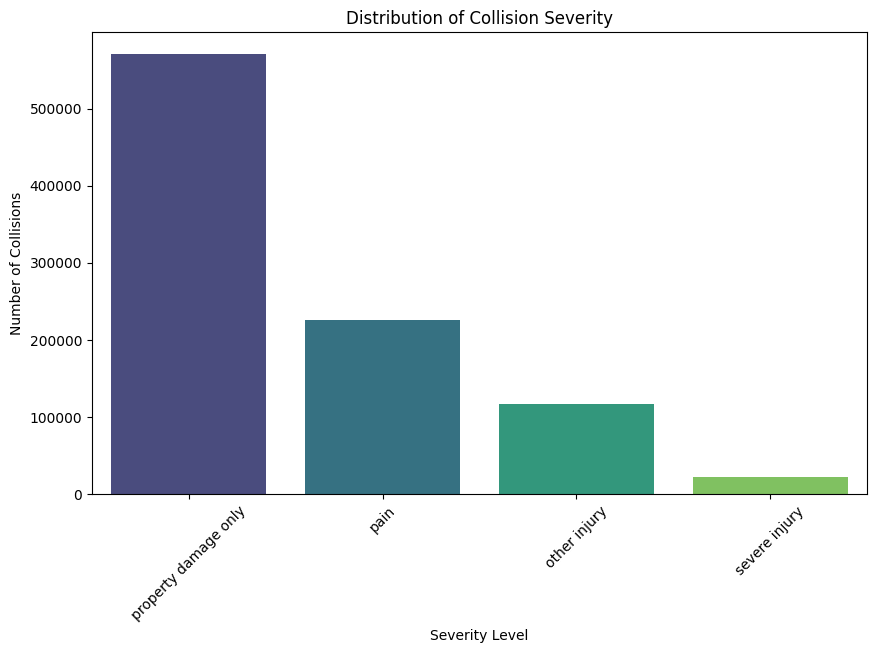

In [ ]:
# Univariate Analysis

# Collision Severity Distribution
severity_counts = collisions_df.groupBy("collision_severity") \
                               .count() \
                               .orderBy(col("count").desc())

import matplotlib.pyplot as plt
import seaborn as sns

# Convert to Pandas
severity_pd = severity_counts.toPandas()

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=severity_pd, x='collision_severity', y='count', palette='viridis')
plt.title('Distribution of Collision Severity')
plt.xlabel('Severity Level')
plt.ylabel('Number of Collisions')
plt.xticks(rotation=45) # Rotates labels for better readability
plt.show()

##**3.1.3. Weather conditions during collisions.** <font color = red>[5 marks]</font> <br>

Q: Examine weather conditions during collisions.

/tmp/ipykernel_4700/350050557.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weather_pd, x='weather_condition', y='count', palette='coolwarm')


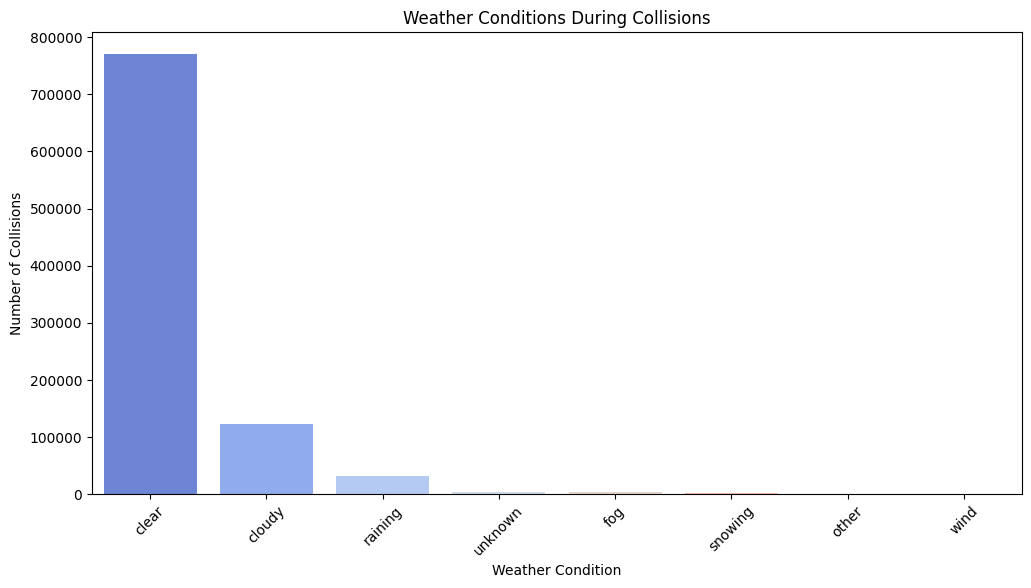

In [ ]:
# Weather Conditions During Collisions
weather_counts = collisions_df.groupBy("weather_condition") \
                               .count() \
                               .orderBy(col("count").desc())

# Convert to Pandas
weather_pd = weather_counts.toPandas()

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=weather_pd, x='weather_condition', y='count', palette='coolwarm')
plt.title('Weather Conditions During Collisions')
plt.xlabel('Weather Condition')
plt.ylabel('Number of Collisions')
plt.xticks(rotation=45)
plt.show()


##**3.1.4. Victime Age Distribution.** <font color = red>[5 marks]</font> <br>

Q: Analyze the distribution of victim ages.

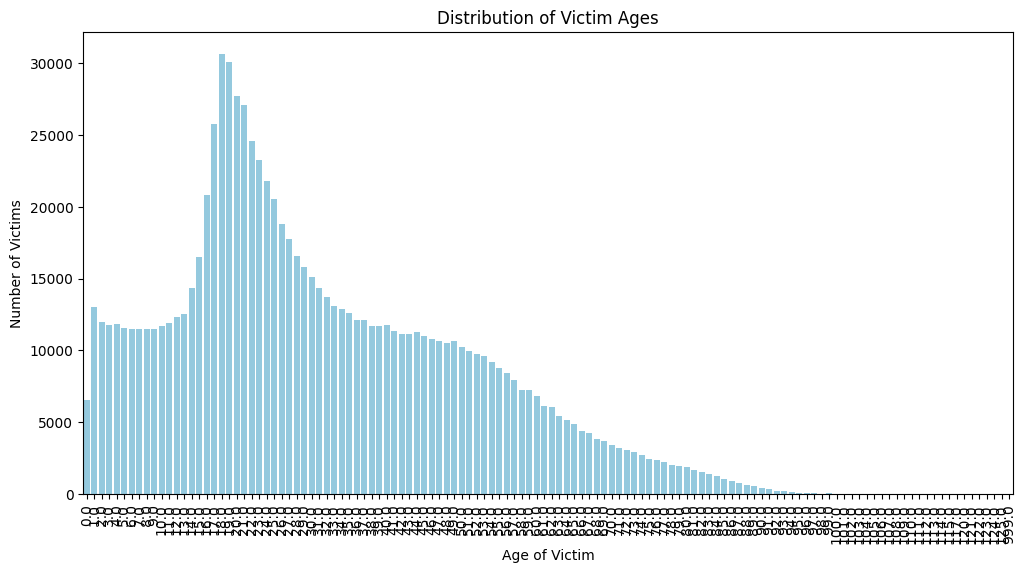

In [ ]:
# Distribution of Victim Ages
age_counts = victims_df.groupBy("victim_age") \
                       .count() \
                       .orderBy("victim_age")

# Convert to Pandas
age_pd = age_counts.toPandas()

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=age_pd, x='victim_age', y='count', color='skyblue')
plt.title('Distribution of Victim Ages')
plt.xlabel('Age of Victim')
plt.ylabel('Number of Victims')
plt.xticks(rotation=90) # Rotates age labels to fit
plt.show()

##**3.1.5. Collision Severity vs Number of Victims.** <font color = red>[5 marks]</font> <br>

Q: Study the relationship between collision severity and the number of victims.

/tmp/ipykernel_4700/3404223855.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=severity_victims_pd, x='collision_severity', y='total_injured', palette='magma')


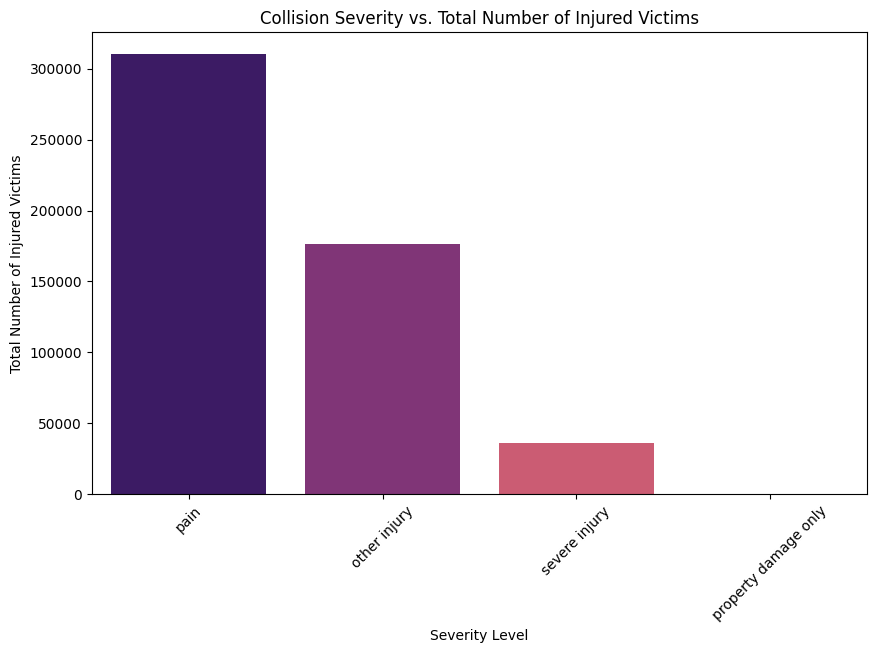

In [ ]:
# Bivariate Analysis

# Collision Severity vs. Number of Victims
severity_vs_victims = collisions_df.groupBy("collision_severity") \
                                   .agg(sum("injured_victims").alias("total_injured")) \
                                   .orderBy(col("total_injured").desc())

# Convert to Pandas
severity_victims_pd = severity_vs_victims.toPandas()

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=severity_victims_pd, x='collision_severity', y='total_injured', palette='magma')
plt.title('Collision Severity vs. Total Number of Injured Victims')
plt.xlabel('Severity Level')
plt.ylabel('Total Number of Injured Victims')
plt.xticks(rotation=45)
plt.show()

##**3.1.6. Weather Conditions vs Collision Severity.** <font color = red>[5 marks]</font> <br>

Q: Analyze the correlation between weather conditions and collision severity.

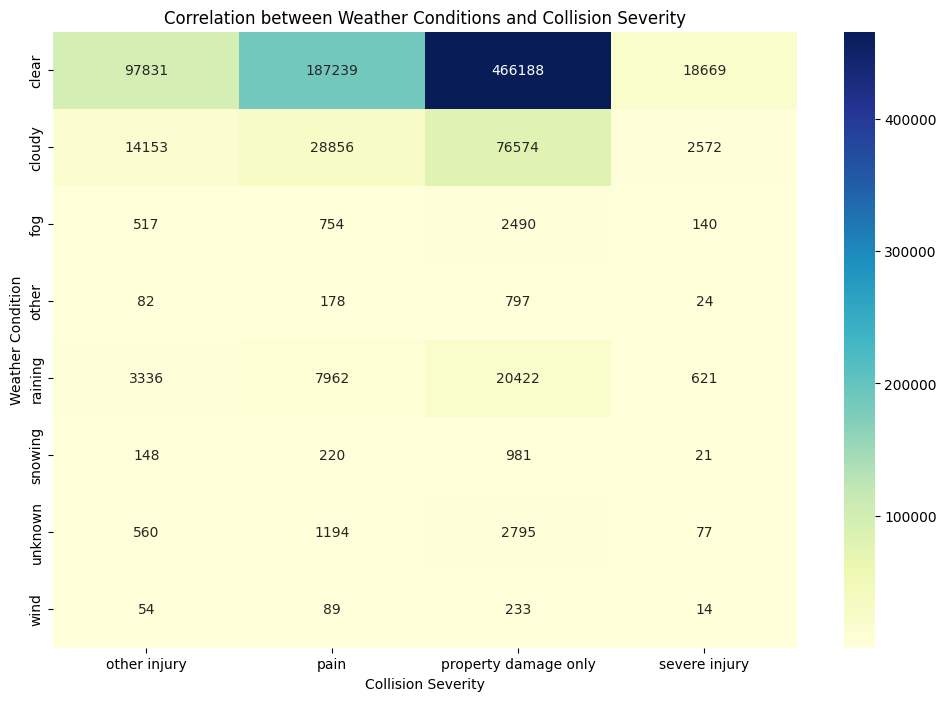

In [ ]:
# Weather vs. Collision Severity
weather_severity_counts = collisions_df.groupBy("weather_condition", "collision_severity") \
                                       .count() \
                                       .orderBy("weather_condition", "collision_severity")

# Convert to Pandas
weather_severity_pd = weather_severity_counts.toPandas()

# Pivot the data: weather as index, severity as columns
weather_severity_pivot = weather_severity_pd.pivot(index='weather_condition',
                                                   columns='collision_severity',
                                                   values='count').fillna(0)

# Plot
plt.figure(figsize=(12, 8))
sns.heatmap(weather_severity_pivot, annot=True, fmt='g', cmap='YlGnBu')
plt.title('Correlation between Weather Conditions and Collision Severity')
plt.xlabel('Collision Severity')
plt.ylabel('Weather Condition')
plt.show()

##**3.1.7. Lighting conditions vs Collision Severity.** <font color = red>[5 marks]</font> <br>

Q:Visualize the impact of lighting conditions on collision severity.

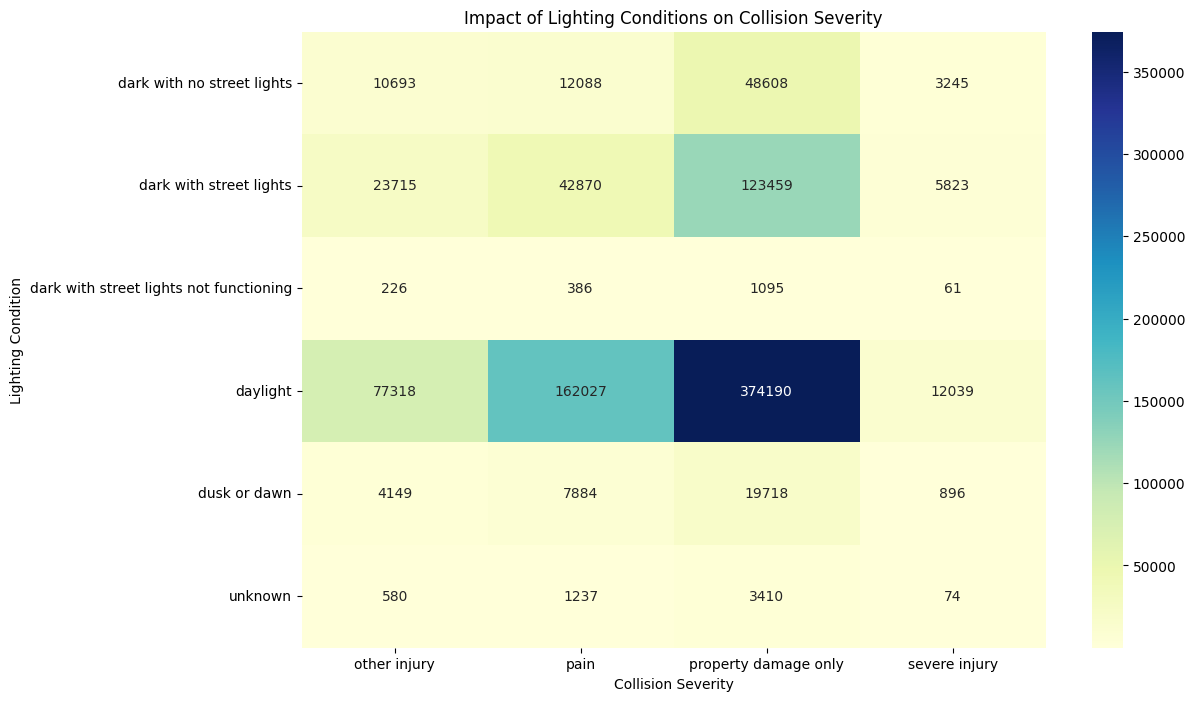

In [ ]:
# Lighting Conditions vs. Collision Severity
lighting_severity_counts = collisions_df.groupBy("lighting", "collision_severity") \
                                       .count() \
                                       .orderBy("lighting", "collision_severity")

# Convert to Pandas
lighting_severity_pd = lighting_severity_counts.toPandas()

# Pivot the data: lighting as index, severity as columns
lighting_severity_pivot = lighting_severity_pd.pivot(index='lighting',
                                                     columns='collision_severity',
                                                     values='count').fillna(0)

# Plot
plt.figure(figsize=(12, 8))
sns.heatmap(lighting_severity_pivot, annot=True, fmt='g', cmap='YlGnBu')
plt.title('Impact of Lighting Conditions on Collision Severity')
plt.xlabel('Collision Severity')
plt.ylabel('Lighting Condition')
plt.show()

##**3.1.8. Weekday-Wise Collision Trends.** <font color = red>[7 marks]</font> <br>

Q: Extract and analyze weekday-wise collision trends.

     weekday   count
1     Monday  131332
5    Tuesday  136972
6  Wednesday  137294
4   Thursday  138713
0     Friday  154544
2   Saturday  127855
3     Sunday  109081


/tmp/ipykernel_4700/1408899600.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weekday_pd, x='weekday', y='count', palette='viridis')


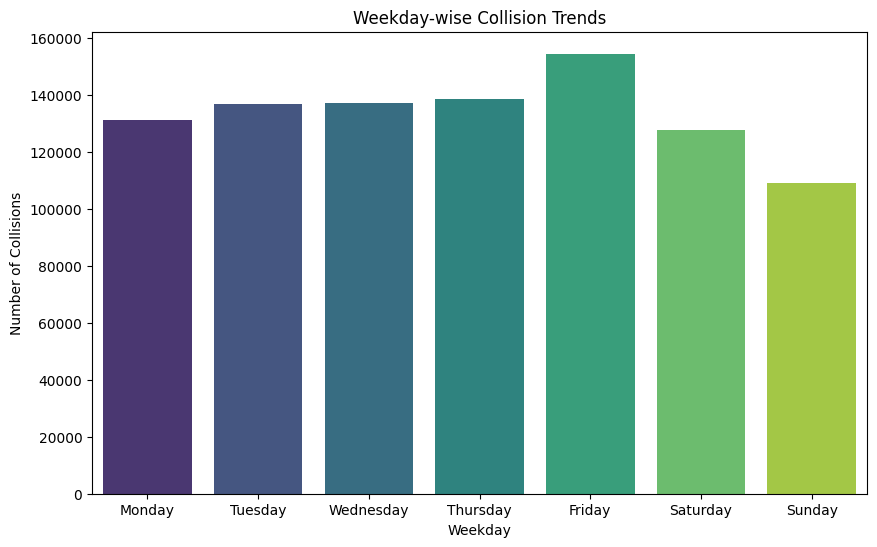

In [ ]:
# Extract the weekday
collisions_df = collisions_df.withColumn("collision_date", to_date(col("collision_date"), "yyyy-MM-dd"))
collisions_df = collisions_df.withColumn("weekday", date_format(col("collision_date"), "EEEE"))

# Aggregate counts per weekday
weekday_counts = collisions_df.groupBy("weekday") \
                              .count() \
                              .orderBy("weekday")

# Convert to Pandas for plotting
weekday_pd = weekday_counts.toPandas()

# Define the order of days
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_pd['weekday'] = pd.Categorical(weekday_pd['weekday'], categories=days_order, ordered=True)
weekday_pd = weekday_pd.sort_values('weekday')

print(weekday_pd)


# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=weekday_pd, x='weekday', y='count', palette='viridis')
plt.title('Weekday-wise Collision Trends')
plt.xlabel('Weekday')
plt.ylabel('Number of Collisions')
plt.show()


##**3.1.9. Spatial Distribution of Collisions.** <font color = red>[7 marks]</font> <br>

Q: Study spatial distribution of collisions by county.

/tmp/ipykernel_4700/430101438.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=county_pd, x='count', y='county_location', palette='viridis')


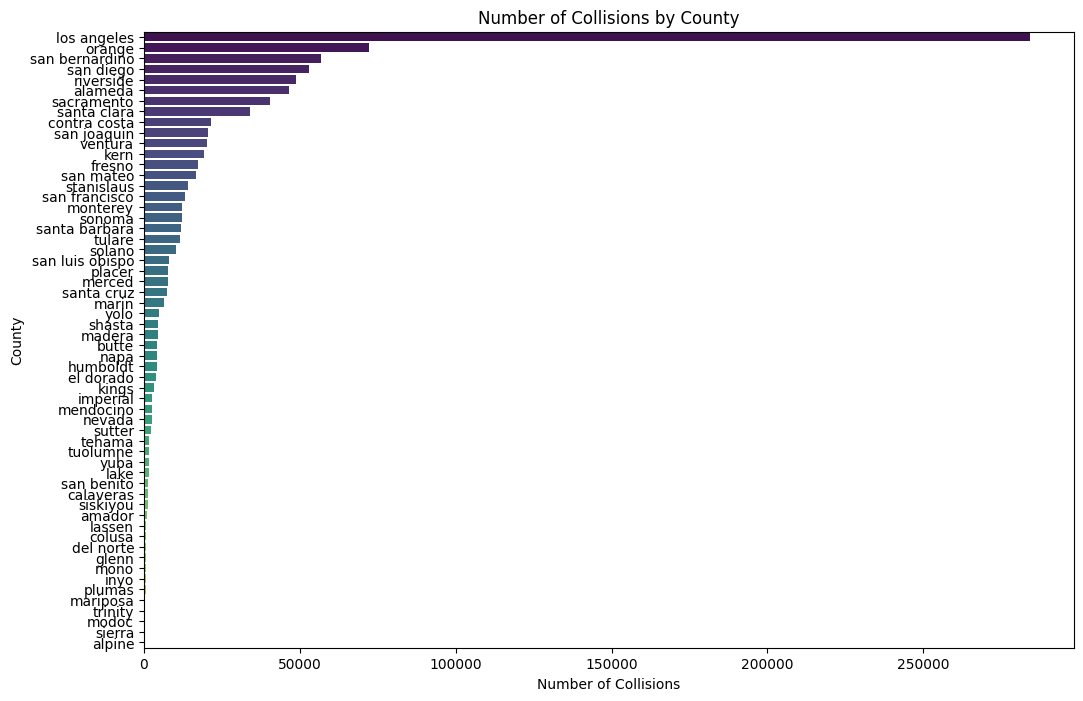

In [ ]:
# Spatial Analysis

# Collision Density by County
county_counts = collisions_df.groupBy("county_location") \
                             .count() \
                             .orderBy(col("count").desc())

# Convert to Pandas
county_pd = county_counts.toPandas()

# Plot the map
plt.figure(figsize=(12, 8))
sns.barplot(data=county_pd, x='count', y='county_location', palette='viridis')
plt.title('Number of Collisions by County')
plt.xlabel('Number of Collisions')
plt.ylabel('County')
plt.show()

##**3.1.10. Collision Analysis by Geography.** <font color = red>[6 marks]</font> <br>

Q: Generate a scatter plot to analyze collision locations geographically.

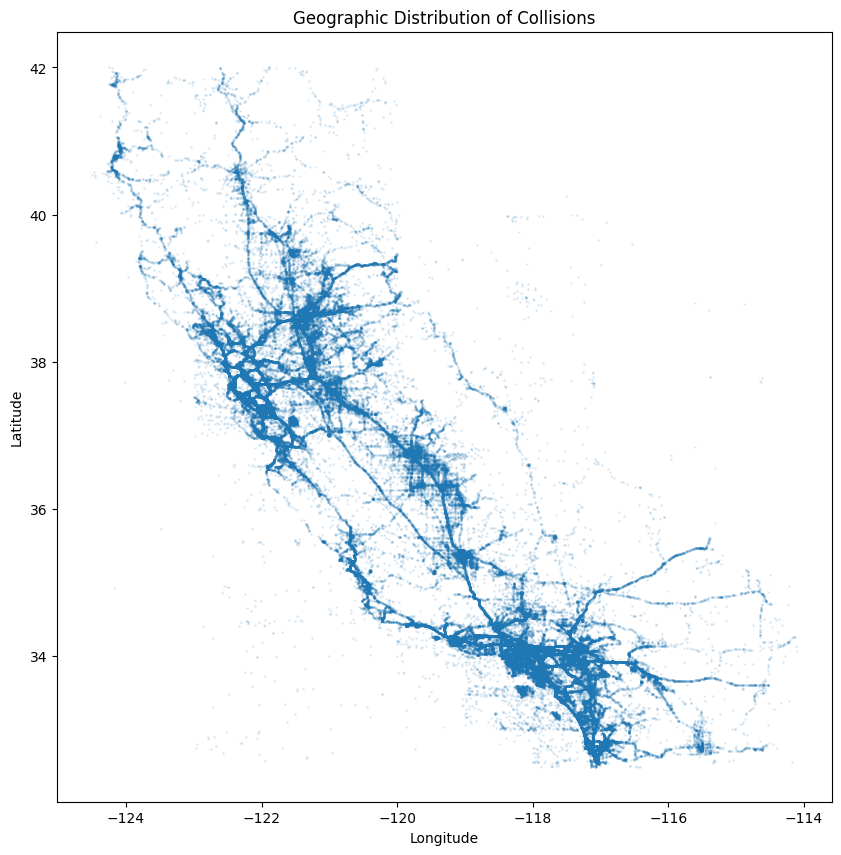

In [ ]:
# Scatter Plot of Collision Locations

# Filter out rows where latitude or longitude are null
spatial_df = collisions_df.filter(col("latitude").isNotNull() & col("longitude").isNotNull()) \
                          .select("latitude", "longitude")

# Convert PySpark DataFrame to Pandas, handling potential missing values
spatial_pd = spatial_df.toPandas()

# Convert to numeric (if needed) and handle invalid data
spatial_pd['latitude'] = pd.to_numeric(spatial_pd['latitude'], errors='coerce')
spatial_pd['longitude'] = pd.to_numeric(spatial_pd['longitude'], errors='coerce')

# Plot the scatter plot
plt.figure(figsize=(10, 10))
# 's' controls dot size, 'alpha' controls transparency (useful for dense datasets)
plt.scatter(spatial_pd['longitude'], spatial_pd['latitude'], s=1, alpha=0.1)
plt.title('Geographic Distribution of Collisions')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

##**3.1.11. Collision Trends Over Time.** <font color = red>[10 marks]</font> <br>

Extract and analyzing collision trends over time.

In [ ]:
from pyspark.sql.functions import year, month, hour, to_timestamp, col

# Extract year and month from collision_date
collisions_df = collisions_df.withColumn("year", year(col("collision_date"))) \
                             .withColumn("month", month(col("collision_date"))) \
                             .withColumn("hour", hour(col("collision_time")))


Q: Analyze yearly, monthly and hourly trends in collisions.

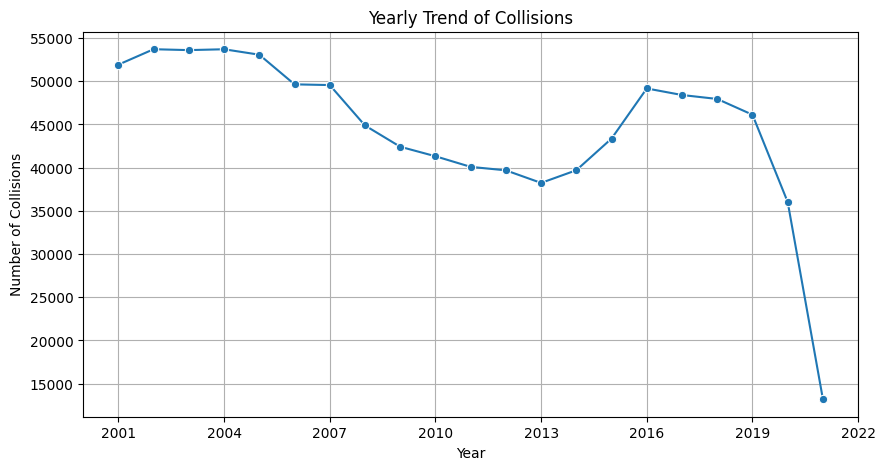

In [ ]:
import matplotlib.ticker as ticker

# Yearly Trend of Collisions
yearly_counts = collisions_df.groupBy("year").count().orderBy("year")

# Convert to Pandas
yearly_pd = yearly_counts.toPandas()

# Cast the year column to integer
yearly_pd['year'] = yearly_pd['year'].astype(int)

# Plot
plt.figure(figsize=(10, 5))
sns.lineplot(data=yearly_pd, x='year', y='count', marker='o')

# Force the x-axis to only show integer years
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.title('Yearly Trend of Collisions')
plt.xlabel('Year')
plt.ylabel('Number of Collisions')
plt.grid(True)
plt.show()

/tmp/ipykernel_4700/1452938250.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_pd, x='month', y='count', palette='viridis')


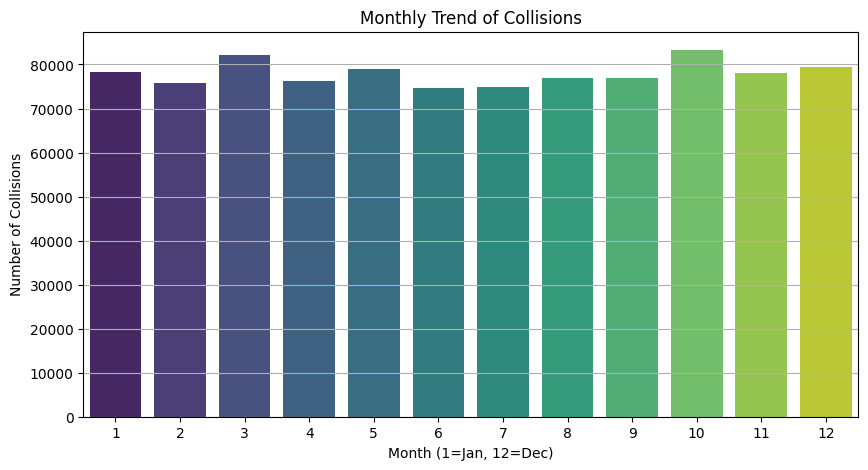

In [ ]:

# Monthly Trend of Collisions
monthly_counts = collisions_df.groupBy("month").count().orderBy("month")

# Convert to Pandas
monthly_pd = monthly_counts.toPandas()

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=monthly_pd, x='month', y='count', palette='viridis')
plt.title('Monthly Trend of Collisions')
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Number of Collisions')
plt.grid(axis='y')
plt.show()

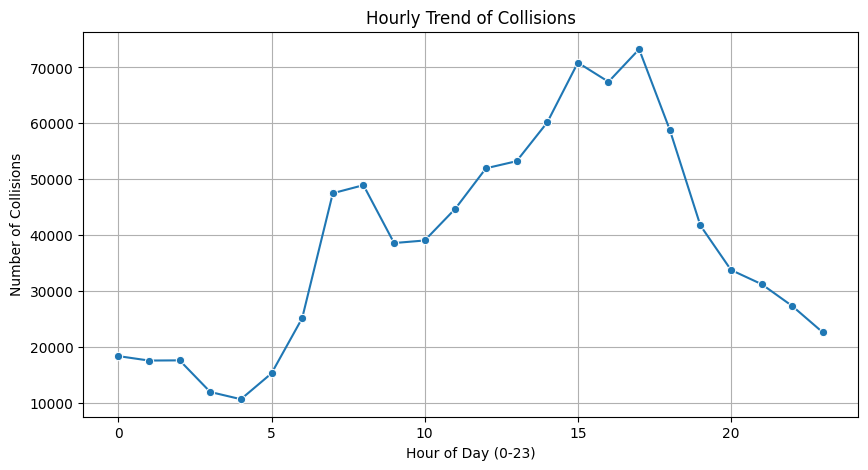

In [ ]:
# Hourly Trend of Collisions
hourly_counts = collisions_df.groupBy("hour").count().orderBy("hour")

# Convert to Pandas
hourly_pd = hourly_counts.toPandas()

# Plot
plt.figure(figsize=(10, 5))
sns.lineplot(data=hourly_pd, x='hour', y='count', marker='o')
plt.title('Hourly Trend of Collisions')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Collisions')
plt.grid(True)
plt.show()

#**4. ETL Querying** <font color = red>[35 marks]</font> <br>

## **4.1. Top 5 Counties** <font color = red>[4 marks]</font> <br>

Q: Identify the top 5 counties with the highest number of collisions.

In [ ]:
# Query: Identify the top 5 counties with the most collisions
top_counties = collisions_df.groupBy("county_location") \
                            .count() \
                            .orderBy(col("count").desc()) \
                            .limit(5)
top_counties.show()


+---------------+------+
|county_location| count|
+---------------+------+
|    los angeles|284100|
|         orange| 72042|
| san bernardino| 56737|
|      san diego| 53105|
|      riverside| 48686|
+---------------+------+



## **4.2. Month with Highest Collisions** <font color = red>[5 marks]</font> <br>

Q. Identify the month with the highest number of collisions.

In [ ]:
# Query: Find the month with the highest number of collisions
highest_month = collisions_df.groupBy("month") \
                             .count() \
                             .orderBy(col("count").desc()) \
                             .limit(1)
highest_month.show()

+-----+-----+
|month|count|
+-----+-----+
|   10|83274|
+-----+-----+



## **4.3. Weather Conditions with Highest Collisions.** <font color = red>[5 marks]</font> <br>

Q. Determine the most common weather condition during collisions.

In [ ]:
# Query: Find the most common weather condition during collisions
most_common_weather = collisions_df.groupBy("weather_condition") \
                                   .count() \
                                   .orderBy(col("count").desc()) \
                                   .limit(1)
most_common_weather.show()


+-----------------+------+
|weather_condition| count|
+-----------------+------+
|            clear|769927|
+-----------------+------+



## **4.4. Fatal Collisions.** <font color = red>[5 marks]</font> <br>

Q. Calculate the percentage of collisions that resulted in fatalities.

In [ ]:
# Query: Determine the percentage of collisions that resulted in fatalities

# Get total collisions
total_count = collisions_df.count()
print(f"Total collisions: {total_count}")

# Get fatal collisions
fatal_count = collisions_df.filter(col("killed_victims") > 0).count()
print(f"Fatal collisions: {fatal_count}")


# Calculate percentage
percentage_fatalities = (fatal_count / total_count) * 100
print(f"Percentage of fatal collisions: {percentage_fatalities:.2f}%")

Total collisions: 935791
Fatal collisions: 0
Percentage of fatal collisions: 0.00%


## **4.5. Dangerous Time for Collisions.** <font color = red>[5 marks]</font> <br>

Q. Find the most dangerous time of day for collisions.

In [ ]:
# Query: Find the most dangerous time of day for collisions
most_dangerous_time = collisions_df.groupBy("hour") \
                                   .count() \
                                   .orderBy(col("count").desc()) \
                                   .limit(1)
most_dangerous_time.show()


+----+-----+
|hour|count|
+----+-----+
|  17|73255|
+----+-----+



## **4.6. Road Surface Conditions.** <font color = red>[5 marks]</font> <br>

Q. Identify the top 5 road surface conditions with the highest collision frequency.

In [ ]:
# Query: List the top 5 road types with the highest collision frequency
top_road_types = collisions_df.groupBy("road_surface") \
                               .count() \
                               .orderBy(col("count").desc()) \
                               .limit(5)
top_road_types.show()


+------------+------+
|road_surface| count|
+------------+------+
|         dry|845637|
|         wet| 76833|
|     unknown|  8141|
|       snowy|  4122|
|    slippery|  1048|
+------------+------+



## **4.7. Lighting Conditions.** <font color = red>[5 marks]</font> <br>

Q. Analyze lighting conditions that contribute to the highest number of collisions.

In [ ]:
# Query: Find the top 3 lighting conditions that lead to the most collisions
top_lighting_conditions = collisions_df.groupBy("lighting") \
                                       .count() \
                                       .orderBy(col("count").desc()) \
                                       .limit(3)
top_lighting_conditions.show()


+--------------------+------+
|            lighting| count|
+--------------------+------+
|            daylight|625574|
|dark with street ...|195867|
|dark with no stre...| 74634|
+--------------------+------+



#5. Conclusion <font color = red>[10 marks]</font> <br>

Write your conclusion.

In [ ]:
# Final insights and recommendations is written below this as text:

Analysis of the Statewide Integrated Traffic Records System (SWITRS) data presents an accurate depiction of patterns, severity, and contributors to traffic accidents in California. Through the application of data cleaning and exploration, consistent trends were observed which could be used to improve traffic safety measures.


# Key Insights
*   Spatial Distribution: Most of the collisions happen in areas of high population density in cities; Los Angeles County is ranked as the top county with many traffic accidents, followed by Orange, San Bernardino, San Diego, and Riverside counties.
*   Temporal Patterns: There are temporal patterns of collisions, where there is an obvious spike in traffic accidents around the time of rush hour, specifically in the late afternoon, which is around 5:00 PM, as well as having a higher tendency to happen on Fridays.
*   Severity and Environment: Although property damage is the predominant outcome of most traffic accidents, high-risk conditions depend on the interaction between lighting and weather. It has been shown that most traffic accidents take place on clear and bright days, because they are the most common driving conditions, yet the heavy traffic at this time of day greatly affects the number of accidents.


# Recommendations
*   Infrastructure and Management: As the peak collision period corresponds with the evening rush hour period, it is important for the local traffic department to plan for optimum signal timings and traffic enforcement at the peak of 5:00 PM.
*   Preventive Measures: With infrastructure improvement efforts, such as improved lighting along streets identified as risky in our geographic scatter plot analysis, risk factors linked with poor visibility while driving can be reduced.
*   Policy and Awareness: In view of the fact that adverse weather is a less common but related factor to certain accidents, the need for public education campaigns on lowering speed and safe distance during rain or fog is recommended.


# Limitations and Data Integrity
It is important to mention that this analysis is done with respect to the given historical dataset which operates for a certain period of time. Data cleaning included deletion of duplicates and handling of sparseness in some columns such as chp_vehicle_type_towed and postmile to ensure validity of our models. Those observations which had no latitude and longitude values have been omitted from geospatial mapping. Predictive modeling could be further built up in subsequent research to predict the areas where collisions are likely to occur.


#6. Visualization Integration using Tableau/ PowerBI <font color = red>[Optional]</font> <br>